In [1]:
import torch
from torch import Tensor, nn
from math import ceil
import numpy as np
from torch.autograd import Function
import os
from torch.autograd.function import Function
import triton
from copy import deepcopy
import triton.language as tl

DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(DEVICE)

cuda


In [2]:
import argparse
import itertools

import torch
import triton
import triton.language as tl
import triton.profiler as proton
from triton.tools.tensor_descriptor import TensorDescriptor
from contextlib import contextmanager

from typing import Optional

if torch.cuda.is_available():
    from triton._C.libtriton import nvidia
    cublas_workspace = torch.empty(32 * 1024 * 1024, device="cuda", dtype=torch.uint8)
    cublas = nvidia.cublas.CublasLt(cublas_workspace)
else:
    cublas = None


def pad_tensor_16_byte_aligned(t: Tensor, axis: int) -> Tensor:
    assert t.ndim == 2, f"expected tensor to have exactly 2 dimensions, got {t.ndims}"
    old_dims = t.shape
    dim = old_dims[axis]
    padded_dim = dim + 16 - dim % 16
    new_dims = (padded_dim, t.shape[1]) if axis == 0 else (t.shape[0], padded_dim)
    new_t = torch.zeros(new_dims, dtype=t.dtype, device=t.device)
    new_t[:old_dims[0], :old_dims[1]] = t
    return new_t


def is_cuda():
    return triton.runtime.driver.active.get_current_target().backend == "cuda"


def supports_tma():
    return is_cuda() and torch.cuda.get_device_capability()[0] >= 9


def is_hopper():
    return torch.cuda.get_device_capability()[0] == 9


def supports_ws():
    return is_cuda() and torch.cuda.get_device_capability()[0] >= 9


def _matmul_launch_metadata(grid, kernel, args):
    ret = {}
    M, N, K, WS = args["M"], args["N"], args["K"], args.get("WARP_SPECIALIZE", False)
    ws_str = "_ws" if WS else ""
    ret["name"] = f"{kernel.name}{ws_str} [M={M}, N={N}, K={K}]"
    if "c_ptr" in args:
        bytes_per_elem = args["c_ptr"].element_size()
    else:
        bytes_per_elem = 1 if args["FP8_OUTPUT"] else 2
    ret[f"flops{bytes_per_elem * 8}"] = 2. * M * N * K
    ret["bytes"] = bytes_per_elem * (M * K + N * K + M * N)
    return ret


HAS_TENSOR_DESC = supports_tma() and hasattr(tl, "make_tensor_descriptor")
HAS_HOST_TENSOR_DESC = supports_tma() and hasattr(triton.tools.tensor_descriptor, "TensorDescriptor")
HAS_WARP_SPECIALIZE = supports_ws() and HAS_TENSOR_DESC


def matmul_get_configs(pre_hook=None):
    return [
        triton.Config({'BLOCK_SIZE_M': BM, 'BLOCK_SIZE_N': BN, "BLOCK_SIZE_K": BK, "GROUP_SIZE_M": 8}, num_stages=s,
                      num_warps=w, pre_hook=pre_hook)
        for BM in [128]
        for BN in [128, 256]
        for BK in [64, 128]
        for s in ([2, 3, 4])
        for w in [4, 8]
    ]


@triton.autotune(
    configs=matmul_get_configs(),
    key=["M", "N", "K"],
)
@triton.jit(launch_metadata=_matmul_launch_metadata)
def matmul_kernel(a_ptr, b_ptr, c_ptr,  #
                  M, N, K,  #
                  stride_am, stride_ak,  #
                  stride_bk, stride_bn,  #
                  stride_cm, stride_cn,  #
                  BLOCK_SIZE_M: tl.constexpr,  #
                  BLOCK_SIZE_N: tl.constexpr,  #
                  BLOCK_SIZE_K: tl.constexpr,  #
                  GROUP_SIZE_M: tl.constexpr,  #
                  ):
    pid = tl.program_id(axis=0)
    num_pid_m = tl.cdiv(M, BLOCK_SIZE_M)
    num_pid_n = tl.cdiv(N, BLOCK_SIZE_N)
    num_pid_in_group = GROUP_SIZE_M * num_pid_n
    group_id = pid // num_pid_in_group
    first_pid_m = group_id * GROUP_SIZE_M
    group_size_m = min(num_pid_m - first_pid_m, GROUP_SIZE_M)
    pid_m = first_pid_m + (pid % group_size_m)
    pid_n = (pid % num_pid_in_group) // group_size_m

    start_m = pid_m * BLOCK_SIZE_M
    start_n = pid_n * BLOCK_SIZE_N

    offs_am = start_m + tl.arange(0, BLOCK_SIZE_M)
    offs_bn = start_n + tl.arange(0, BLOCK_SIZE_N)
    offs_am = tl.where(offs_am < M, offs_am, 0)
    offs_bn = tl.where(offs_bn < N, offs_bn, 0)

    offs_am = tl.max_contiguous(tl.multiple_of(offs_am, BLOCK_SIZE_M), BLOCK_SIZE_M)
    offs_bn = tl.max_contiguous(tl.multiple_of(offs_bn, BLOCK_SIZE_N), BLOCK_SIZE_N)
    offs_k = tl.arange(0, BLOCK_SIZE_K)
    a_ptrs = a_ptr + (offs_am[:, None] * stride_am + offs_k[None, :] * stride_ak)
    b_ptrs = b_ptr + (offs_k[:, None] * stride_bk + offs_bn[None, :] * stride_bn)

    accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)

    for k in range(0, tl.cdiv(K, BLOCK_SIZE_K)):
        a = tl.load(a_ptrs, mask=offs_k[None, :] < K - k * BLOCK_SIZE_K, other=0.0)
        b = tl.load(b_ptrs, mask=offs_k[:, None] < K - k * BLOCK_SIZE_K, other=0.0)
        accumulator = tl.dot(a, b, accumulator)
        a_ptrs += BLOCK_SIZE_K * stride_ak
        b_ptrs += BLOCK_SIZE_K * stride_bk

    if (c_ptr.dtype.element_ty == tl.float8e4nv):
        c = accumulator.to(tl.float8e4nv)
    else:
        c = accumulator.to(tl.float16)

    offs_cm = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
    offs_cn = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
    c_ptrs = c_ptr + stride_cm * offs_cm[:, None] + stride_cn * offs_cn[None, :]
    c_mask = (offs_cm[:, None] < M) & (offs_cn[None, :] < N)
    tl.store(c_ptrs, c, mask=c_mask)


def matmul(a, b):
    # Check constraints.
    assert a.shape[1] == b.shape[0], "Incompatible dimensions"
    assert a.dtype == b.dtype, "Incompatible dtypes"
    M, K = a.shape
    K, N = b.shape
    dtype = a.dtype

    c = torch.empty((M, N), device=a.device, dtype=dtype)
    # 1D launch kernel where each block gets its own program.
    grid = lambda META: (triton.cdiv(M, META["BLOCK_SIZE_M"]) * triton.cdiv(N, META["BLOCK_SIZE_N"]), )
    matmul_kernel[grid](
        a, b, c,  #
        M, N, K,  #
        a.stride(0), a.stride(1),  #
        b.stride(0), b.stride(1),  #
        c.stride(0), c.stride(1),  #
    )
    return c


def matmul_tma_set_block_size_hook(nargs):
    EPILOGUE_SUBTILE = nargs.get("EPILOGUE_SUBTILE", False)
    BLOCK_M = nargs["BLOCK_SIZE_M"]
    BLOCK_N = nargs["BLOCK_SIZE_N"]
    BLOCK_K = nargs["BLOCK_SIZE_K"]
    nargs["a_desc"].block_shape = [BLOCK_M, BLOCK_K]
    nargs["b_desc"].block_shape = [BLOCK_N, BLOCK_K]
    if EPILOGUE_SUBTILE:
        nargs["c_desc"].block_shape = [BLOCK_M, BLOCK_N // 2]
    else:
        nargs["c_desc"].block_shape = [BLOCK_M, BLOCK_N]


@triton.autotune(
    configs=matmul_get_configs(pre_hook=matmul_tma_set_block_size_hook),
    key=["M", "N", "K", "WARP_SPECIALIZE"],
)
@triton.jit(launch_metadata=_matmul_launch_metadata)
def matmul_kernel_tma(a_desc, b_desc, c_desc,  #
                      M, N, K,  #
                      BLOCK_SIZE_M: tl.constexpr,  #
                      BLOCK_SIZE_N: tl.constexpr,  #
                      BLOCK_SIZE_K: tl.constexpr,  #
                      GROUP_SIZE_M: tl.constexpr,  #
                      FP8_OUTPUT: tl.constexpr,  #
                      WARP_SPECIALIZE: tl.constexpr,  #
                      ):
    dtype = tl.float8e4nv if FP8_OUTPUT else tl.float16

    pid = tl.program_id(axis=0)
    num_pid_m = tl.cdiv(M, BLOCK_SIZE_M)
    num_pid_n = tl.cdiv(N, BLOCK_SIZE_N)
    num_pid_in_group = GROUP_SIZE_M * num_pid_n
    group_id = pid // num_pid_in_group
    first_pid_m = group_id * GROUP_SIZE_M
    group_size_m = min(num_pid_m - first_pid_m, GROUP_SIZE_M)
    pid_m = first_pid_m + (pid % group_size_m)
    pid_n = (pid % num_pid_in_group) // group_size_m

    k_tiles = tl.cdiv(K, BLOCK_SIZE_K)

    offs_am = pid_m * BLOCK_SIZE_M
    offs_bn = pid_n * BLOCK_SIZE_N

    accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)

    for k in tl.range(k_tiles, warp_specialize=WARP_SPECIALIZE):
        offs_k = k * BLOCK_SIZE_K
        a = a_desc.load([offs_am, offs_k])
        b = b_desc.load([offs_bn, offs_k])
        accumulator = tl.dot(a, b.T, accumulator)

    c = accumulator.to(dtype)

    offs_cm = pid_m * BLOCK_SIZE_M
    offs_cn = pid_n * BLOCK_SIZE_N
    c_desc.store([offs_cm, offs_cn], c)


def matmul_tma(a, b, warp_specialize: bool = True):
    # Check constraints.
    assert a.shape[1] == b.shape[1], "Incompatible dimensions"  # b is transposed
    assert a.dtype == b.dtype, "Incompatible dtypes"

    M, K = a.shape
    N, K = b.shape
    dtype = a.dtype

    if K % 16 != 0:
        a = pad_tensor_16_byte_aligned(a, axis=1)
        b = pad_tensor_16_byte_aligned(b, axis=0)

    if N % 16 != 0:
        b = pad_tensor_16_byte_aligned(b, axis=1)
        old_N = N
        
    M, K = a.shape
    _, N = b.shape

    c = torch.empty((M, N), device=a.device, dtype=dtype)

    # A dummy block value that will be overwritten when we have the real block size
    dummy_block = [1, 1]
    a_desc = TensorDescriptor.from_tensor(a, dummy_block)
    b_desc = TensorDescriptor.from_tensor(b, dummy_block)
    c_desc = TensorDescriptor.from_tensor(c, dummy_block)

    def grid(META):
        BLOCK_M = META["BLOCK_SIZE_M"]
        BLOCK_N = META["BLOCK_SIZE_N"]
        return (triton.cdiv(M, BLOCK_M) * triton.cdiv(N, BLOCK_N), )

    matmul_kernel_tma[grid](
        a_desc, b_desc, c_desc,  #
        M, N, K,  #
        FP8_OUTPUT=dtype == torch.float8_e4m3fn,  #
        WARP_SPECIALIZE=warp_specialize,  #
    )

    c = c[:, :old_N]
    return c


@triton.jit
def _compute_pid(tile_id, num_pid_in_group, num_pid_m, GROUP_SIZE_M, NUM_SMS):
    group_id = tile_id // num_pid_in_group
    first_pid_m = group_id * GROUP_SIZE_M
    group_size_m = min(num_pid_m - first_pid_m, GROUP_SIZE_M)
    pid_m = first_pid_m + (tile_id % group_size_m)
    pid_n = (tile_id % num_pid_in_group) // group_size_m
    return pid_m, pid_n


@triton.autotune(
    configs=matmul_get_configs(),
    key=["M", "N", "K"],
)
@triton.jit(launch_metadata=_matmul_launch_metadata)
def matmul_kernel_persistent(a_ptr, b_ptr, c_ptr,  #
                             M, N, K,  #
                             stride_am, stride_ak,  #
                             stride_bk, stride_bn,  #
                             stride_cm, stride_cn,  #
                             BLOCK_SIZE_M: tl.constexpr,  #
                             BLOCK_SIZE_N: tl.constexpr,  #
                             BLOCK_SIZE_K: tl.constexpr,  #
                             GROUP_SIZE_M: tl.constexpr,  #
                             NUM_SMS: tl.constexpr,  #
                             ):
    start_pid = tl.program_id(axis=0)
    num_pid_m = tl.cdiv(M, BLOCK_SIZE_M)
    num_pid_n = tl.cdiv(N, BLOCK_SIZE_N)
    k_tiles = tl.cdiv(K, BLOCK_SIZE_K)
    num_tiles = num_pid_m * num_pid_n

    # NOTE: There is currently a bug in blackwell pipelining that means it can't handle a value being
    # used in both the prologue and epilogue, so we duplicate the counters as a work-around.
    tile_id_c = start_pid - NUM_SMS

    offs_k_for_mask = tl.arange(0, BLOCK_SIZE_K)
    num_pid_in_group = GROUP_SIZE_M * num_pid_n

    for tile_id in tl.range(start_pid, num_tiles, NUM_SMS, flatten=True, warp_specialize=True):
        pid_m, pid_n = _compute_pid(tile_id, num_pid_in_group, num_pid_m, GROUP_SIZE_M, NUM_SMS)
        start_m = pid_m * BLOCK_SIZE_M
        start_n = pid_n * BLOCK_SIZE_N
        offs_am = start_m + tl.arange(0, BLOCK_SIZE_M)
        offs_bn = start_n + tl.arange(0, BLOCK_SIZE_N)
        offs_am = tl.where(offs_am < M, offs_am, 0)
        offs_bn = tl.where(offs_bn < N, offs_bn, 0)
        offs_am = tl.max_contiguous(tl.multiple_of(offs_am, BLOCK_SIZE_M), BLOCK_SIZE_M)
        offs_bn = tl.max_contiguous(tl.multiple_of(offs_bn, BLOCK_SIZE_N), BLOCK_SIZE_N)

        accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
        for ki in range(k_tiles):
            offs_k = ki * BLOCK_SIZE_K + tl.arange(0, BLOCK_SIZE_K)
            a_ptrs = a_ptr + (offs_am[:, None] * stride_am + offs_k[None, :] * stride_ak)
            b_ptrs = b_ptr + (offs_k[:, None] * stride_bk + offs_bn[None, :] * stride_bn)

            a = tl.load(a_ptrs, mask=offs_k_for_mask[None, :] < K - ki * BLOCK_SIZE_K, other=0.0)
            b = tl.load(b_ptrs, mask=offs_k_for_mask[:, None] < K - ki * BLOCK_SIZE_K, other=0.0)
            accumulator = tl.dot(a, b, accumulator)

        tile_id_c += NUM_SMS
        pid_m, pid_n = _compute_pid(tile_id_c, num_pid_in_group, num_pid_m, GROUP_SIZE_M, NUM_SMS)
        offs_cm = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
        offs_cn = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
        c_ptrs = c_ptr + stride_cm * offs_cm[:, None] + stride_cn * offs_cn[None, :]
        c_mask = (offs_cm[:, None] < M) & (offs_cn[None, :] < N)
        if (c_ptr.dtype.element_ty == tl.float8e4nv):
            c = accumulator.to(tl.float8e4nv)
        else:
            c = accumulator.to(tl.float16)
        tl.store(c_ptrs, c, mask=c_mask)


def matmul_persistent(a, b):
    # Check constraints.
    assert a.shape[1] == b.shape[0], "Incompatible dimensions"
    assert a.dtype == b.dtype, "Incompatible dtypes"
    NUM_SMS = torch.cuda.get_device_properties("cuda").multi_processor_count
    M, K = a.shape
    K, N = b.shape
    dtype = a.dtype
    # Allocates output.
    c = torch.empty((M, N), device=a.device, dtype=dtype)
    # 1D launch kernel where each block gets its own program.
    grid = lambda META: (min(NUM_SMS, triton.cdiv(M, META["BLOCK_SIZE_M"]) * triton.cdiv(N, META["BLOCK_SIZE_N"])), )
    matmul_kernel_persistent[grid](
        a, b, c,  #
        M, N, K,  #
        a.stride(0), a.stride(1),  #
        b.stride(0), b.stride(1),  #
        c.stride(0), c.stride(1),  #
        NUM_SMS=NUM_SMS,  #
    )
    return c


def matmul_tma_persistent_get_configs(pre_hook=None):
    return [
        triton.Config(
            {
                'BLOCK_SIZE_M': BM, 'BLOCK_SIZE_N': BN, "BLOCK_SIZE_K": BK, "GROUP_SIZE_M": 8, "EPILOGUE_SUBTILE":
                SUBTILE
            }, num_stages=s, num_warps=w, pre_hook=pre_hook)  #
        for BM in [128]  #
        for BN in [128, 256]  #
        for BK in [64, 128]  #
        for s in ([2, 3, 4])  #
        for w in [4, 8]  #
        for SUBTILE in [True, False]  #
    ]


@triton.autotune(
    configs=matmul_tma_persistent_get_configs(pre_hook=matmul_tma_set_block_size_hook),
    key=["M", "N", "K", "WARP_SPECIALIZE"],
)
@triton.jit(launch_metadata=_matmul_launch_metadata)
def matmul_kernel_tma_persistent(a_desc, b_desc, c_desc,  #
                                 M, N, K,  #
                                 BLOCK_SIZE_M: tl.constexpr,  #
                                 BLOCK_SIZE_N: tl.constexpr,  #
                                 BLOCK_SIZE_K: tl.constexpr,  #
                                 GROUP_SIZE_M: tl.constexpr,  #
                                 FP8_OUTPUT: tl.constexpr,  #
                                 EPILOGUE_SUBTILE: tl.constexpr,  #
                                 NUM_SMS: tl.constexpr,  #
                                 WARP_SPECIALIZE: tl.constexpr,  #
                                 ):
    dtype = tl.float8e4nv if FP8_OUTPUT else tl.float16
    start_pid = tl.program_id(axis=0)
    num_pid_m = tl.cdiv(M, BLOCK_SIZE_M)
    num_pid_n = tl.cdiv(N, BLOCK_SIZE_N)
    k_tiles = tl.cdiv(K, BLOCK_SIZE_K)
    num_tiles = num_pid_m * num_pid_n

    tile_id_c = start_pid - NUM_SMS
    num_pid_in_group = GROUP_SIZE_M * num_pid_n

    # Enable warp specialization to leverage async warp scheduling in the GPU.
    # FIXME: This only works on Blackwell right now. On older GPUs, this will
    # use software pipelining.
    for tile_id in tl.range(start_pid, num_tiles, NUM_SMS, flatten=True, warp_specialize=WARP_SPECIALIZE):
        pid_m, pid_n = _compute_pid(tile_id, num_pid_in_group, num_pid_m, GROUP_SIZE_M, NUM_SMS)
        offs_am = pid_m * BLOCK_SIZE_M
        offs_bn = pid_n * BLOCK_SIZE_N

        accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
        for ki in range(k_tiles):
            offs_k = ki * BLOCK_SIZE_K
            a = a_desc.load([offs_am, offs_k])
            b = b_desc.load([offs_bn, offs_k])
            accumulator = tl.dot(a, b.T, accumulator)

        tile_id_c += NUM_SMS
        pid_m, pid_n = _compute_pid(tile_id_c, num_pid_in_group, num_pid_m, GROUP_SIZE_M, NUM_SMS)
        offs_am_c = pid_m * BLOCK_SIZE_M
        offs_bn_c = pid_n * BLOCK_SIZE_N

        # Epilogue subtiling is a technique to break our computation and stores into multiple pieces
        # By subtiling we can reduce shared memory consumption by the epilogue and instead use that
        # memory to increase our stage count.
        # In this case we partition the accumulator into 2 BLOCK_SIZE_M x BLOCK_SIZE_N // 2 tensors
        if EPILOGUE_SUBTILE:
            acc = tl.reshape(accumulator, (BLOCK_SIZE_M, 2, BLOCK_SIZE_N // 2))
            acc = tl.permute(acc, (0, 2, 1))
            acc0, acc1 = tl.split(acc)
            c0 = acc0.to(dtype)
            c_desc.store([offs_am_c, offs_bn_c], c0)
            c1 = acc1.to(dtype)
            c_desc.store([offs_am_c, offs_bn_c + BLOCK_SIZE_N // 2], c1)
        else:
            accumulator = accumulator.to(dtype)
            c_desc.store([offs_am_c, offs_bn_c], accumulator)


def matmul_tma_persistent(a, b, warp_specialize: bool = True):
    # Check constraints.
    assert a.shape[1] == b.shape[1], "Incompatible dimensions"  # b is transposed
    assert a.dtype == b.dtype, "Incompatible dtypes"

    M, K = a.shape
    N, K = b.shape
    dtype = a.dtype

    ### pad if needed (tensor_descriptor expecting stride(0) to 
    # be multiple of 16 -> K, N must be so)
    if K % 16 != 0:
        a = pad_tensor_16_byte_aligned(a, axis=1)
        b = pad_tensor_16_byte_aligned(b, axis=0)

    if N % 16 != 0:
        b = pad_tensor_16_byte_aligned(b, axis=1)
        old_N = N
        
    M, K = a.shape
    _, N = b.shape
    
    c = torch.empty((M, N), device=a.device, dtype=dtype)

    NUM_SMS = torch.cuda.get_device_properties("cuda").multi_processor_count

    # A dummy block value that will be overwritten when we have the real block size
    dummy_block = [1, 1]
    a_desc = TensorDescriptor.from_tensor(a, dummy_block)
    b_desc = TensorDescriptor.from_tensor(b, dummy_block)
    c_desc = TensorDescriptor.from_tensor(c, dummy_block)

    def grid(META):
        nonlocal a_desc, b_desc, c_desc
        BLOCK_M = META["BLOCK_SIZE_M"]
        BLOCK_N = META["BLOCK_SIZE_N"]
        return (min(
            NUM_SMS,
            triton.cdiv(M, BLOCK_M) * triton.cdiv(N, BLOCK_N),
        ), )

    matmul_kernel_tma_persistent[grid](
        a_desc, b_desc, c_desc,  #
        M, N, K,  #
        FP8_OUTPUT=dtype == torch.float8_e4m3fn,  #
        NUM_SMS=NUM_SMS,  #
        WARP_SPECIALIZE=warp_specialize,  #
    )
    c = c[:, :old_N]
    return c


def prune_invalid_configs(configs, named_args, **kwargs):
    FLATTEN = kwargs["FLATTEN"]
    # Filter out configs where EPILOGUE_SUBTILE is true and HOPPER is true
    return [conf for conf in configs if not (conf.kwargs.get("EPILOGUE_SUBTILE", True) and FLATTEN is False)]


@triton.autotune(configs=matmul_tma_persistent_get_configs(), key=["M", "N", "K", "WARP_SPECIALIZE", "FLATTEN"],
                 prune_configs_by={'early_config_prune': prune_invalid_configs})
@triton.jit(launch_metadata=_matmul_launch_metadata)
def matmul_kernel_descriptor_persistent(
    a_ptr,
    b_ptr,
    c_ptr,  #
    M,
    N,
    K,  #
    BLOCK_SIZE_M: tl.constexpr,  #
    BLOCK_SIZE_N: tl.constexpr,  #
    BLOCK_SIZE_K: tl.constexpr,  #
    GROUP_SIZE_M: tl.constexpr,  #
    EPILOGUE_SUBTILE: tl.constexpr,  #
    NUM_SMS: tl.constexpr,  #
    WARP_SPECIALIZE: tl.constexpr,  #
    FLATTEN: tl.constexpr,
):
    # Matmul using TMA and device-side descriptor creation
    dtype = c_ptr.dtype.element_ty
    start_pid = tl.program_id(axis=0)
    num_pid_m = tl.cdiv(M, BLOCK_SIZE_M)
    num_pid_n = tl.cdiv(N, BLOCK_SIZE_N)
    k_tiles = tl.cdiv(K, BLOCK_SIZE_K)
    num_tiles = num_pid_m * num_pid_n

    a_desc = tl.make_tensor_descriptor(
        a_ptr,
        shape=[M, K],
        strides=[K, 1],
        block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_K],
    )
    b_desc = tl.make_tensor_descriptor(
        b_ptr,
        shape=[N, K],
        strides=[K, 1],
        block_shape=[BLOCK_SIZE_N, BLOCK_SIZE_K],
    )
    c_desc = tl.make_tensor_descriptor(
        c_ptr,
        shape=[M, N],
        strides=[N, 1],
        block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_N if not EPILOGUE_SUBTILE else BLOCK_SIZE_N // 2],
    )

    # tile_id_c is used in the epilogue to break the dependency between
    # the prologue and the epilogue
    tile_id_c = start_pid - NUM_SMS
    num_pid_in_group = GROUP_SIZE_M * num_pid_n

    for tile_id in tl.range(start_pid, num_tiles, NUM_SMS, flatten=FLATTEN, warp_specialize=WARP_SPECIALIZE):
        pid_m, pid_n = _compute_pid(tile_id, num_pid_in_group, num_pid_m, GROUP_SIZE_M, NUM_SMS)
        offs_am = pid_m * BLOCK_SIZE_M
        offs_bn = pid_n * BLOCK_SIZE_N

        accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
        for ki in range(k_tiles):
            offs_k = ki * BLOCK_SIZE_K
            a = a_desc.load([offs_am, offs_k])
            b = b_desc.load([offs_bn, offs_k])
            accumulator = tl.dot(a, b.T, accumulator)

        tile_id_c += NUM_SMS
        pid_m, pid_n = _compute_pid(tile_id_c, num_pid_in_group, num_pid_m, GROUP_SIZE_M, NUM_SMS)
        offs_cm = pid_m * BLOCK_SIZE_M
        offs_cn = pid_n * BLOCK_SIZE_N

        if EPILOGUE_SUBTILE:
            acc = tl.reshape(accumulator, (BLOCK_SIZE_M, 2, BLOCK_SIZE_N // 2))
            acc = tl.permute(acc, (0, 2, 1))
            acc0, acc1 = tl.split(acc)
            c0 = acc0.to(dtype)
            c_desc.store([offs_cm, offs_cn], c0)
            c1 = acc1.to(dtype)
            c_desc.store([offs_cm, offs_cn + BLOCK_SIZE_N // 2], c1)
        else:
            c = accumulator.to(dtype)
            c_desc.store([offs_cm, offs_cn], c)


def matmul_descriptor_persistent(a, b, warp_specialize: bool = True):
    # Check constraints.
    assert a.shape[1] == b.shape[1], "Incompatible dimensions"  # b is transposed
    assert a.dtype == b.dtype, "Incompatible dtypes"

    M, K = a.shape
    N, K = b.shape
    dtype = a.dtype

    c = torch.empty((M, N), device=a.device, dtype=dtype)
    NUM_SMS = torch.cuda.get_device_properties("cuda").multi_processor_count

    # TMA descriptors require a global memory allocation
    def alloc_fn(size: int, alignment: int, stream: Optional[int]):
        return torch.empty(size, device="cuda", dtype=torch.int8)

    triton.set_allocator(alloc_fn)

    # Hopper warpspec doesn't work with flatten
    flatten = False if (warp_specialize and is_hopper()) else True
    grid = lambda META: (min(NUM_SMS, triton.cdiv(M, META["BLOCK_SIZE_M"]) * triton.cdiv(N, META["BLOCK_SIZE_N"])), )
    matmul_kernel_descriptor_persistent[grid](
        a,
        b,
        c,  #
        M,
        N,
        K,  #
        NUM_SMS=NUM_SMS,  #
        WARP_SPECIALIZE=warp_specialize,  #
        FLATTEN=flatten,
    )
    return c



def get_cuda_autotune_config():
    return [
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=3,
                      num_warps=8),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4,
                      num_warps=4),
        triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=5,
                      num_warps=2),
        triton.Config({'BLOCK_SIZE_M': 32, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=5,
                      num_warps=2),
        # Good config for fp8 inputs.
        # triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=3,
        #               num_warps=8),
        # triton.Config({'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=3,
        #               num_warps=8),
        # triton.Config({'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=4,
        #               num_warps=4),
        # triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=4,
        #               num_warps=4),
        # triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=4,
        #               num_warps=4),
        # triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=4,
        #               num_warps=4),
        # triton.Config({'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=4,
        #               num_warps=4),
        # triton.Config({'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=4,
        #               num_warps=4),
        triton.Config(
            {'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8},
            num_stages=4, num_warps=8
        ),

        triton.Config(
            {'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8},
            num_stages=4, num_warps=8
        ),

        triton.Config(
            {'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8},
            num_stages=4, num_warps=8
        ),

        # Push Blackwell/B200 TC pipes
        triton.Config(
            {'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 256, 'GROUP_SIZE_M': 8},
            num_stages=5, num_warps=16
        ),
    ]


def get_hip_autotune_config():
    sizes = [
        {'BLOCK_SIZE_M': 32, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 6},
        {'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 4},
        {'BLOCK_SIZE_M': 32, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 6},
        {'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 6},
        {'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 4},
        {'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 4},
        {'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 4},
        {'BLOCK_SIZE_M': 256, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 6},
    ]
    return [triton.Config(s | {'matrix_instr_nonkdim': 16}, num_warps=8, num_stages=2) for s in sizes]


def get_autotune_config():
    if is_cuda():
        return get_cuda_autotune_config()
    else:
        return get_hip_autotune_config()

@triton.autotune(
    configs=get_autotune_config(),
    key=['M', 'N', 'K'],
)
@triton.jit()
def _eager_matmul_triton(
    a_ptr,
    b_ptr,
    c_ptr,
    M,
    N,
    K,
    stride_am,
    stride_ak,
    stride_bk,
    stride_bn,
    stride_cm,
    stride_cn,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr,
):

    pid = tl.program_id(axis=0)

    #
    n_programs_n = tl.cdiv(N, BLOCK_SIZE_N)

    # map global pid to (pid_m, pid_n)
    pid_m = pid // n_programs_n
    pid_n = pid % n_programs_n

    # offsets along dimensions m, n, k
    offset_ptr_m = (pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)) % M
    offset_ptr_n = (pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)) % N
    offset_ptr_k = tl.arange(0, BLOCK_SIZE_K)

    # get pointers for first tiles tile_a, tile_b
    tile_a_ptr = a_ptr + (
        offset_ptr_m[:, None] * stride_am + offset_ptr_k[None, :] * stride_ak
    )
    tile_b_ptr = b_ptr + (
        offset_ptr_k[:, None] * stride_bk + offset_ptr_n[None, :] * stride_bn
    )

    tile_c = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)

    # loop over dimension k
    for k in tl.range(0, tl.cdiv(K, BLOCK_SIZE_K)):

        # if K % k != 0 -> mask out the items after K
        items_after_K = K - k * BLOCK_SIZE_K

        # materialize the masks along the Z dimenison for tile_a, tile_b
        # mask_ak = offset_ptr_k[None, :] < items_after_K # mask along 1st dim
        # mask_bk = offset_ptr_k[:, None] < items_after_K # mask along 2nd dim

        # Create masks that check BOTH dimensions
        # For A: Check M (rows) AND K (cols)
        mask_ak = offset_ptr_k[None, :] < items_after_K

        # # For B: Check K (rows) AND N (cols)
        mask_bk = offset_ptr_k[:, None] < items_after_K
        # mask_bk = (offset_ptr_n[None, :] < N)

        tile_a = tl.load(tile_a_ptr, mask_ak, other=0.0)
        tile_b = tl.load(tile_b_ptr, mask_bk, other=0.0)

        tile_c = tl.dot(tile_a, tile_b, acc=tile_c)

        # now slide the tile_a, tile_b pointers along Z direction of BLOCK_SIZE_K steps
        tile_a_ptr += BLOCK_SIZE_K * stride_ak
        tile_b_ptr += BLOCK_SIZE_K * stride_bk

    tile_c = tile_c.to(tl.bfloat16)

    # get c global pointers and store the output
    tile_c_ptr = (
        c_ptr + offset_ptr_m[:, None] * stride_cm + offset_ptr_n[None, :] * stride_cn
    )
    mask_c = (offset_ptr_m[:, None] < M) & (offset_ptr_n[None, :] < N)
    tl.store(tile_c_ptr, tile_c, mask=mask_c)


def eager_matmul(a: Tensor, b: Tensor):
    assert a.ndim == 2, "expected A to have ndim=2"
    assert b.ndim == 2, "expected B to have ndim=2"
    assert a.shape[1] == b.shape[0], "dimension mismatch"

    M, K = a.shape
    N = b.shape[1]

    c = torch.empty((M, N), device=a.device, dtype=a.dtype)
    # c = torch.zeros(M, N).to(DEVICE)

    # these will be tuned via autotune and provided as metaparameters
    block_size_M, block_size_N, block_size_K = (128, 128, 64)
    # block_size_M, block_size_N, block_size_K = (8, 8, 4)
    group_size_M = 8
    # block_size_M, block_size_N, block_size_K = (2, 2, 2)

    grid = lambda META: (triton.cdiv(M, META['BLOCK_SIZE_M']) * triton.cdiv(N, META['BLOCK_SIZE_N']), )
    # grid = (ceil(M / block_size_M) * ceil(N / block_size_N),)

    _eager_matmul_triton[grid](
        a,
        b,
        c,
        M,
        N,
        K,
        a.stride(0),
        a.stride(1),
        b.stride(0),
        b.stride(1),
        c.stride(0),
        c.stride(1),
        # BLOCK_SIZE_M,
        # BLOCK_SIZE_N,
        # BLOCK_SIZE_K,
        # group_size_M,
    )

    return c





@triton.jit()
def map_pid_m_n(pid, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M, optimize_L2):
    if optimize_L2:
        pid_m, pid_n = map_pid_m_n_L2_optim(
            pid, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M
        )
    else:
        n_programs_n = tl.cdiv(N, BLOCK_SIZE_N)
        pid_m = pid // n_programs_n
        pid_n = pid % n_programs_n
    return (pid_m, pid_n)


@triton.jit()
def map_pid_m_n_L2_optim(pid, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M):

    num_blocks_n = tl.cdiv(N, BLOCK_SIZE_N)
    num_blocks_m = tl.cdiv(M, BLOCK_SIZE_M)
    num_programs_in_group = GROUP_SIZE_M * num_blocks_n

    group_size_m = GROUP_SIZE_M
    offset_m = pid // num_programs_in_group
    group_size_m = min(GROUP_SIZE_M, num_blocks_m - offset_m * GROUP_SIZE_M)

    pid_m = ((pid % num_programs_in_group) % group_size_m) + offset_m * GROUP_SIZE_M
    pid_n = (pid % num_programs_in_group) // group_size_m

    return (pid_m, pid_n)

@triton.autotune(
    configs=get_autotune_config(),
    key=['M', 'N', 'K'],
)
@triton.jit()
def _descriptor_block_matmul_triton(
    a_ptr,
    b_ptr,
    c_ptr,
    M,
    N,
    K,
    # stride_am,
    # stride_ak,
    # stride_bk,
    # stride_bn,
    # stride_cm,
    # stride_cn,
    optimize_L2,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr,
):

    ### create tensor descriptors for a, b, c
    a_desc = tl.make_tensor_descriptor(
        a_ptr, 
        shape=[M, K], 
        strides=[K, 1], 
        block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_K]
    )

    b_desc = tl.make_tensor_descriptor(
        b_ptr, shape=[K, N], strides=[N, 1], block_shape=[BLOCK_SIZE_K, BLOCK_SIZE_N]
    )

    c_desc = tl.make_tensor_descriptor(
        c_ptr, shape=[M, N], strides=[N, 1], block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_N]
    )

    pid = tl.program_id(axis=0)
    pid_m, pid_n = map_pid_m_n(
        pid, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M, optimize_L2
    )

    # Add some integer bound assumptions.
    # This helps to guide integer analysis in the backend to optimize
    # load/store offset address calculation
    tl.assume(pid_m >= 0)
    tl.assume(pid_n >= 0)
    # tl.assume(stride_am > 0)
    # tl.assume(stride_ak > 0)
    # tl.assume(stride_bn > 0)
    # tl.assume(stride_bk > 0)
    # tl.assume(stride_cm > 0)
    # tl.assume(stride_cn > 0)

    # offsets along dimensions m, n, k
    offset_ptr_m = pid_m * BLOCK_SIZE_M
    offset_ptr_n = pid_n * BLOCK_SIZE_N

    # get pointers for first tiles tile_a, tile_b
    # tile_a_ptr = a_ptr + (
    #     offset_ptr_m[:, None] * stride_am + offset_ptr_k[None, :] * stride_ak
    # )
    # tile_b_ptr = b_ptr + (
    #     offset_ptr_k[:, None] * stride_bk + offset_ptr_n[None, :] * stride_bn
    # )

    tile_c = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)

    # loop over dimension k
    for k in tl.range(0, tl.cdiv(K, BLOCK_SIZE_K)):

        offset_k = k * BLOCK_SIZE_K
        tile_a = a_desc.load([offset_ptr_m, offset_k])
        tile_b = b_desc.load([offset_k, offset_ptr_n])

        tile_c = tl.dot(tile_a, tile_b, acc=tile_c)

    # get c global pointers and store the output
    c_desc.store([offset_ptr_m, offset_ptr_n], tile_c)


def pad_tensor_16_byte_aligned(t: Tensor, axis: int) -> Tensor:
    assert t.ndim == 2, f"expected tensor to have exactly 2 dimensions, got {t.ndims}"
    old_dims = t.shape
    dim = old_dims[axis]
    padded_dim = dim + 16 - dim % 16
    new_dims = (padded_dim, t.shape[1]) if axis == 0 else (t.shape[0], padded_dim)
    new_t = torch.zeros(new_dims, dtype=t.dtype, device=t.device)
    new_t[:old_dims[0], :old_dims[1]] = t
    return new_t


def matmul_descriptor_block(
    a: Tensor,
    b: Tensor,
    optimize_L2: bool = True,
):

    # validate_inputs_matmul(a, b)

    M, K = a.shape
    _, N = b.shape
    old_N = N
    
    ### pad if needed (tensor_descriptor expecting stride(0) to 
    # be multiple of 16 -> K, N must be so)
    if K % 16 != 0:
        a = pad_tensor_16_byte_aligned(a, axis=1)
        b = pad_tensor_16_byte_aligned(b, axis=0)

    if N % 16 != 0:
        b = pad_tensor_16_byte_aligned(b, axis=1)
        old_N = N
        
    M, K = a.shape
    _, N = b.shape
    
    c = torch.zeros(M, N, device=DEVICE, dtype=a.dtype)

    # grid = lambda META: (ceil(M / META['BLOCK_SIZE_M']) * ceil(N / META['BLOCK_SIZE_N']),)

    # BLOCK_SIZE_M, BLOCK_SIZE_N, BLOCK_SIZE_K, GROUP_SIZE_M = 64, 64, 64, 4
    # BLOCK_SIZE_M, BLOCK_SIZE_N, BLOCK_SIZE_K, GROUP_SIZE_M = 2, 2, 2, 4
    # BLOCK_SIZE_M, BLOCK_SIZE_N, BLOCK_SIZE_K, GROUP_SIZE_M = 2, 2, 2, 1
    # grid = (ceil(M / BLOCK_SIZE_M) * ceil(N / BLOCK_SIZE_N),)
    grid = lambda META: (triton.cdiv(M, META['BLOCK_SIZE_M']) * triton.cdiv(N, META['BLOCK_SIZE_N']), )

    # tma descriptors need a global allocation function
    def allocation_fun(size: int, allignment: int, stream: Optional[int]):
        return torch.empty(size, device=a.device, dtype=torch.int8)
    triton.set_allocator(allocation_fun)

    _descriptor_block_matmul_triton[grid](
        a,
        b,
        c,
        M,
        N,
        K,
        optimize_L2,
        # BLOCK_SIZE_M,
        # BLOCK_SIZE_N,
        # BLOCK_SIZE_K,
        # GROUP_SIZE_M,
    )
    
    c = c[:, :old_N]
    return c if c.dtype == a.dtype else c.to(dtype=a.dtype)



In [3]:
MAP_MATMUL = {
        "torch": torch.matmul,
        "eager" : eager_matmul,
        "eager_L2_optimized": matmul, 
        "eager_L2_optimized_tma" : matmul_tma,
        "persistent" : matmul_persistent,
        "descriptor_block" : matmul_descriptor_block, 
        "descriptor_persistent" : matmul_descriptor_persistent,
        "descriptor_persistent_tma" : matmul_tma_persistent,
}

matmul_names = list(MAP_MATMUL.keys())
colors = ["black", "red", "green", "blue", "yellow", "cyan", "purple", "grey"]


provider='torch', fp8_inputs=True, M=32, N=32, K=32
provider='eager', fp8_inputs=True, M=32, N=32, K=32
provider='eager_L2_optimized', fp8_inputs=True, M=32, N=32, K=32
provider='eager_L2_optimized_tma', fp8_inputs=True, M=32, N=32, K=32
provider='descriptor_block', fp8_inputs=True, M=32, N=32, K=32
provider='descriptor_persistent', fp8_inputs=True, M=32, N=32, K=32
provider='descriptor_persistent_tma', fp8_inputs=True, M=32, N=32, K=32
provider='torch', fp8_inputs=True, M=64, N=64, K=64
provider='eager', fp8_inputs=True, M=64, N=64, K=64
provider='eager_L2_optimized', fp8_inputs=True, M=64, N=64, K=64
provider='eager_L2_optimized_tma', fp8_inputs=True, M=64, N=64, K=64
provider='descriptor_block', fp8_inputs=True, M=64, N=64, K=64
provider='descriptor_persistent', fp8_inputs=True, M=64, N=64, K=64
provider='descriptor_persistent_tma', fp8_inputs=True, M=64, N=64, K=64
provider='torch', fp8_inputs=True, M=128, N=128, K=128
provider='eager', fp8_inputs=True, M=128, N=128, K=128
provider

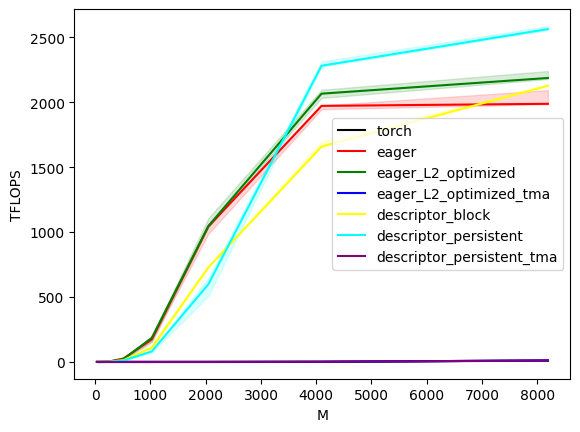

matmul-performance-fp8:
        M       N       K         torch        eager  eager_L2_optimized  eager_L2_optimized_tma  descriptor_block  descriptor_persistent  descriptor_persistent_tma
0    32.0    32.0    32.0  6.553600e-07     0.006737            0.005953            6.553600e-07          0.003230               0.002632               6.553600e-07
1    64.0    64.0    64.0  5.242880e-06     0.063259            0.051360            5.242880e-06          0.027769               0.020454               5.242880e-06
2   128.0   128.0   128.0  4.194304e-05     0.510008            0.407056            4.194304e-05          0.224823               0.172237               4.194304e-05
3   256.0   256.0   256.0  3.355443e-04     3.640889            3.004516            3.355443e-04          1.730323               1.360021               3.355443e-04
4   512.0   512.0   512.0  2.684355e-03    26.214401           21.902370            2.684355e-03         13.617871              10.699755              

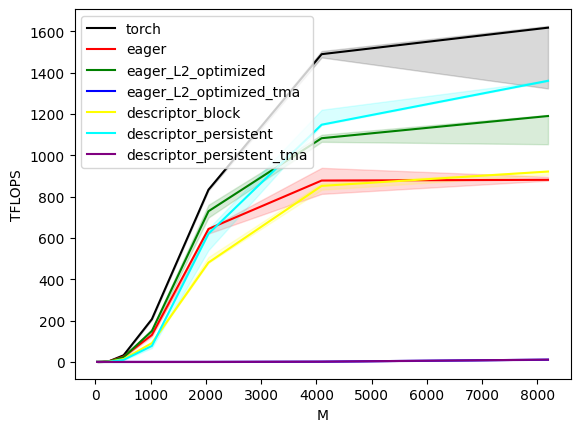

matmul-performance-fp16:
        M       N       K        torch       eager  eager_L2_optimized  eager_L2_optimized_tma  descriptor_block  descriptor_persistent  descriptor_persistent_tma
0    32.0    32.0    32.0     0.007136    0.006671            0.005851            6.553600e-07          0.003256               0.002538               6.553600e-07
1    64.0    64.0    64.0     0.063751    0.055918            0.048188            5.242880e-06          0.027444               0.020531               5.242880e-06
2   128.0   128.0   128.0     0.506070    0.478365            0.386643            4.194304e-05          0.208051               0.161817               4.194304e-05
3   256.0   256.0   256.0     4.032985    3.799188            3.256447            3.355443e-04          1.651301               1.309901               3.355443e-04
4   512.0   512.0   512.0    32.263877   25.731926           22.795130            2.684355e-03         13.797053              10.094595               2.684355e-

In [ ]:

ref_lib = 'cuBLAS' if is_cuda() else 'rocBLAS'
TORCH_HAS_FP8 = hasattr(torch, "float8_e5m2")

configs = []
for fp8_inputs in [False, True]:
    if fp8_inputs and (not TORCH_HAS_FP8 or not is_cuda()):
        continue
    configs.append(
        triton.testing.Benchmark(
            x_names=["M", "N", "K"],  # Argument names to use as an x-axis for the plot
            x_vals=[int(2 ** i) for i in np.arange(5, 14, 1)],  # Different possible values for `x_name`
            line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
            # Possible values for `line_arg`
            # Don't compare to cublas for fp8 cases as torch.matmul doesn't support fp8 at the moment.
            line_vals=matmul_names, #["triton"] if fp8_inputs else [ref_lib.lower(), "triton"],  # Label name for the lines
            line_names=matmul_names, #["Triton"] if fp8_inputs else [ref_lib, "Triton"],  # Line styles
            styles=[(x, "-") for x, _ in zip(colors,matmul_names)], # ("green", "-"), ("blue", "-")],
            ylabel="TFLOPS",  # Label name for the y-axis
            plot_name="matmul-performance-" +
            ("fp16" if not fp8_inputs else "fp8"),  # Name for the plot, used also as a file name for saving the plot.
            args={"fp8_inputs": fp8_inputs},
        ))

@triton.testing.perf_report(configs)
def benchmark(M, N, K, provider, fp8_inputs):
    print(f"{provider=}, {fp8_inputs=}, {M=}, {N=}, {K=}")
    a = torch.randn((M, K), device=DEVICE, dtype=torch.float16)
    b = torch.randn((K, N), device=DEVICE, dtype=torch.float16)
    if TORCH_HAS_FP8 and fp8_inputs:
        a = a.to(torch.float8_e5m2)
        b = b.T
        b = b.to(torch.float8_e5m2)
    quantiles = [0.5, 0.2, 0.8]
    try:
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: MAP_MATMUL[provider](a, b), quantiles=quantiles) 
    except:
        ms, min_ms, max_ms = 3 * [100]

    # if provider == ref_lib.lower():
        # ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.matmul(a, b), quantiles=quantiles)
    # if provider == 'triton':
        # ms, min_ms, max_ms = triton.testing.do_bench(lambda: eager_matmul(a, b), quantiles=quantiles)
    perf = lambda ms: 2 * M * N * K * 1e-12 / (ms * 1e-3)
    return perf(ms), perf(max_ms), perf(min_ms)


benchmark.run(show_plots=True, print_data=True)

provider='torch', fp8_inputs=False, M=42, N=42, K=42
provider='eager', fp8_inputs=False, M=42, N=42, K=42
provider='eager_L2_optimized', fp8_inputs=False, M=42, N=42, K=42
provider='persistent', fp8_inputs=False, M=42, N=42, K=42
provider='descriptor_block', fp8_inputs=False, M=42, N=42, K=42
provider='descriptor_persistent', fp8_inputs=False, M=42, N=42, K=42
provider='torch', fp8_inputs=False, M=74, N=74, K=74
provider='eager', fp8_inputs=False, M=74, N=74, K=74
provider='eager_L2_optimized', fp8_inputs=False, M=74, N=74, K=74
provider='persistent', fp8_inputs=False, M=74, N=74, K=74
provider='descriptor_block', fp8_inputs=False, M=74, N=74, K=74
provider='descriptor_persistent', fp8_inputs=False, M=74, N=74, K=74
provider='torch', fp8_inputs=False, M=138, N=138, K=138
provider='eager', fp8_inputs=False, M=138, N=138, K=138
provider='eager_L2_optimized', fp8_inputs=False, M=138, N=138, K=138
provider='persistent', fp8_inputs=False, M=138, N=138, K=138
provider='descriptor_block', fp8

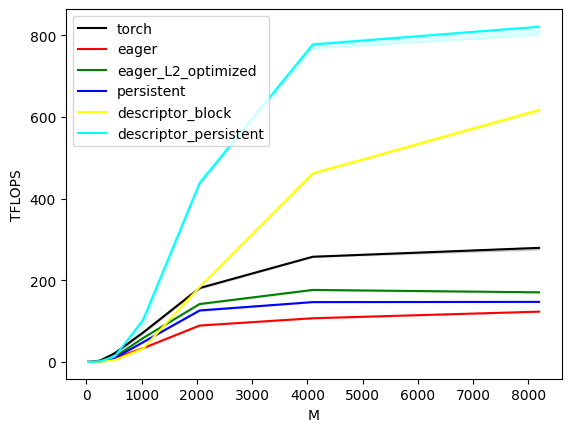

matmul-performance-fp16:
        M       N       K       torch       eager  eager_L2_optimized  persistent  descriptor_block  descriptor_persistent
0    32.0    32.0    32.0    0.018088    0.013230            0.014425    0.009627          0.002417               0.007848
1    64.0    64.0    64.0    0.098932    0.071342            0.071746    0.046901          0.013697               0.043893
2   128.0   128.0   128.0    0.576332    0.364201            0.397711    0.283197          0.088499               0.273757
3   256.0   256.0   256.0    3.699115    1.944328            2.194624    1.666173          0.621404               1.747873
4   512.0   512.0   512.0   21.369689    9.250563           12.127954    9.579515          4.492062              13.228855
5  1024.0  1024.0  1024.0   71.823500   33.688057           58.455334   48.115743         32.599294             102.513658
6  2048.0  2048.0  2048.0  180.927823   89.146404          141.794301  126.017507        183.178777             43

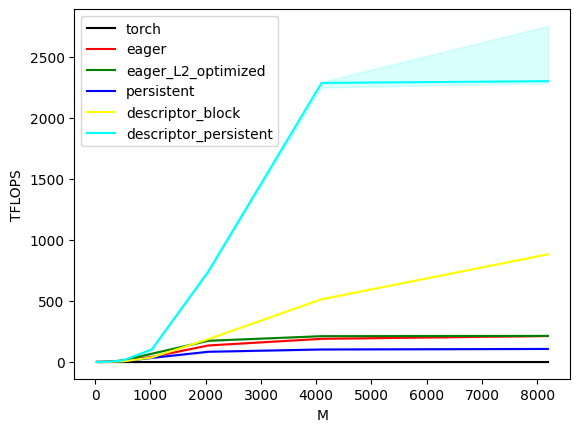

matmul-performance-fp8:
        M       N       K  torch       eager  eager_L2_optimized  persistent  descriptor_block  descriptor_persistent
0    32.0    32.0    32.0    0.0    0.016078            0.013155    0.008948          0.002403               0.007373
1    64.0    64.0    64.0    0.0    0.072155            0.066474    0.043742          0.013386               0.043072
2   128.0   128.0   128.0    0.0    0.398676            0.397711    0.245522          0.085194               0.268390
3   256.0   256.0   256.0    0.0    2.042220            2.440495    1.367812          0.604480               1.837998
4   512.0   512.0   512.0    0.0   10.324960           13.308069    6.945149          4.688708              13.428687
5  1024.0  1024.0  1024.0    0.0   40.739509           67.408982   33.186458         36.499845             102.665983
6  2048.0  2048.0  2048.0    0.0  135.095768          173.660730   83.413518        187.078875             740.181634
7  4096.0  4096.0  4096.0    0.0

In [9]:
MAP_MATMUL = {
        "torch": torch.matmul,
        "eager" : eager_matmul,
        "eager_L2_optimized": matmul, 
        # "eager_L2_optimized_tma" : matmul_tma,
        "persistent" : matmul_persistent,
        "descriptor_block" : matmul_descriptor_block, 
        "descriptor_persistent" : matmul_descriptor_persistent,
        # "descriptor_persistent_tma" : matmul_tma_persistent,
}

matmul_names = list(MAP_MATMUL.keys())
colors = ["black", "red", "green", "blue", "yellow", "cyan", "purple", "grey"]


ref_lib = 'cuBLAS' if is_cuda() else 'rocBLAS'
TORCH_HAS_FP8 = hasattr(torch, "float8_e5m2")

configs = []
for fp8_inputs in [False, True]:
    if fp8_inputs and (not TORCH_HAS_FP8 or not is_cuda()):
        continue
    configs.append(
        triton.testing.Benchmark(
            x_names=["M", "N", "K"],  # Argument names to use as an x-axis for the plot
            x_vals=[int(2 ** i) for i in np.arange(5, 14, 1)],  # Different possible values for `x_name`
            line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
            # Possible values for `line_arg`
            # Don't compare to cublas for fp8 cases as torch.matmul doesn't support fp8 at the moment.
            line_vals=matmul_names, #["triton"] if fp8_inputs else [ref_lib.lower(), "triton"],  # Label name for the lines
            line_names=matmul_names, #["Triton"] if fp8_inputs else [ref_lib, "Triton"],  # Line styles
            styles=[(x, "-") for x, _ in zip(colors,matmul_names)], # ("green", "-"), ("blue", "-")],
            ylabel="TFLOPS",  # Label name for the y-axis
            plot_name="matmul-performance-" +
            ("fp16" if not fp8_inputs else "fp8"),  # Name for the plot, used also as a file name for saving the plot.
            args={"fp8_inputs": fp8_inputs},
        ))


@triton.testing.perf_report(configs)
def benchmark(M, N, K, provider, fp8_inputs):
    M += 10
    N += 10
    K += 10
    print(f"{provider=}, {fp8_inputs=}, {M=}, {N=}, {K=}")
    a = torch.randn((M, K), device=DEVICE, dtype=torch.float16)
    b = torch.randn((K, N), device=DEVICE, dtype=torch.float16)
    if TORCH_HAS_FP8 and fp8_inputs:
        a = a.to(torch.float8_e5m2)
        b = b.T
        b = b.to(torch.float8_e5m2)
    quantiles = [0.5, 0.2, 0.8]
    # try:
    if provider in ["torch"] and fp8_inputs:
        return 3 * [0]
        
    ms, min_ms, max_ms = triton.testing.do_bench(lambda: MAP_MATMUL[provider](a, b), quantiles=quantiles) 
    # except:
        # ms, min_ms, max_ms = 3 * [100]
    # if provider in ["torch", "eager_L2_optimized_tma", "descriptor_persistent_tma"] and fp8_inputs:
    # else:
    # if provider == ref_lib.lower():
        # ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.matmul(a, b), quantiles=quantiles)
    # if provider == 'triton':
        # ms, min_ms, max_ms = triton.testing.do_bench(lambda: eager_matmul(a, b), quantiles=quantiles)
    perf = lambda ms: 2 * M * N * K * 1e-12 / (ms * 1e-3)
    return perf(ms), perf(max_ms), perf(min_ms)


benchmark.run(show_plots=True, print_data=True)

In [40]:
DTYPE = torch.bfloat16
M, K, N = 66, 67, 68
a = torch.rand((M, K), device=DEVICE, dtype=DTYPE)
b = torch.rand((N, K), device=DEVICE, dtype=DTYPE)

c = matmul_descriptor_persistent(a, b)
# c = matmul_tma_persistent(a, b)

In [ ]:

@triton.jit()
def map_pid_m_n(pid, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M, optimize_L2):
    if optimize_L2:
        pid_m, pid_n = map_pid_m_n_L2_optim(
            pid, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M
        )
    else:
        n_programs_n = tl.cdiv(N, BLOCK_SIZE_N)
        pid_m = pid // n_programs_n
        pid_n = pid % n_programs_n
    return (pid_m, pid_n)


@triton.jit()
def map_pid_m_n_L2_optim(pid, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M):

    num_blocks_n = tl.cdiv(N, BLOCK_SIZE_N)
    num_blocks_m = tl.cdiv(M, BLOCK_SIZE_M)
    num_programs_in_group = GROUP_SIZE_M * num_blocks_n

    group_size_m = GROUP_SIZE_M
    offset_m = pid // num_programs_in_group
    group_size_m = min(GROUP_SIZE_M, num_blocks_m - offset_m * GROUP_SIZE_M)

    pid_m = ((pid % num_programs_in_group) % group_size_m) + offset_m * GROUP_SIZE_M
    pid_n = (pid % num_programs_in_group) // group_size_m

    return (pid_m, pid_n)

import math

@triton.jit()
def maybe_pad_16_byte_aligned(n):
    if n % 16 != 0:
        return n + 16 - n % 16
    return n

@triton.jit()
def _matmul_persistent_descriptor_triton(
    a_ptr,
    b_ptr,
    c_ptr,
    M,
    N,
    K,
    NUM_SMS: tl.constexpr,
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr,
):
    
    ### create tensor descriptors for a, b, c
    a_desc = tl.make_tensor_descriptor(
        a_ptr, 
        shape=[M, K], 
        strides=[K, 1], 
        block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_K]
    )

    b_desc = tl.make_tensor_descriptor(
        b_ptr, shape=[K, N], strides=[N, 1], block_shape=[BLOCK_SIZE_K, BLOCK_SIZE_N]
    )

    c_desc = tl.make_tensor_descriptor(
        c_ptr, shape=[M, N], strides=[N, 1], block_shape=[BLOCK_SIZE_M, BLOCK_SIZE_N]
    )

    ### run mamtul loop on multiple tiles
    pid = tl.program_id(axis=0)
    num_tiles_m = tl.cdiv(M, BLOCK_SIZE_M)
    num_tiles_n = tl.cdiv(N, BLOCK_SIZE_N)
    num_tiles = num_tiles_m * num_tiles_n
    

    for tile_id in tl.range(pid, num_tiles, NUM_SMS):
        pid_m, pid_n = map_pid_m_n(
            tile_id, M, N, BLOCK_SIZE_M, BLOCK_SIZE_N, GROUP_SIZE_M, optimize_L2=True
        )
        
        ### with triton tensor_descriptor the offsets are scalar and not 2D like  
        # when using tl.load
        offset_m = pid_m * BLOCK_SIZE_M
        offset_n = pid_n * BLOCK_SIZE_N

        tile_c = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)

        for k in tl.range(0, tl.cdiv(K, BLOCK_SIZE_K)):
            
            offset_k = k * BLOCK_SIZE_K

            tile_a = a_desc.load([offset_m, offset_k])
            tile_b = b_desc.load([offset_k, offset_n])

            tile_c = tl.dot(tile_a, tile_b, acc=tile_c)

        ### store tile_c back im mamory
        c_desc.store([offset_m, offset_n], tile_c)

def pad_tensor_16_byte_aligned(t: Tensor, axis: int) -> Tensor:
    assert t.ndim == 2, f"expected tensor to have exactly 2 dimensions, got {t.ndims}"
    old_dims = t.shape
    dim = old_dims[axis]
    padded_dim = dim + 16 - dim % 16
    new_dims = (padded_dim, t.shape[1]) if axis == 0 else (t.shape[0], padded_dim)
    new_t = torch.zeros(new_dims, dtype=t.dtype, device=t.device)
    new_t[:old_dims[0], :old_dims[1]] = t
    return new_t

def matmul_descriptor_persistent(a: Tensor, b: Tensor, DEBUG: bool = False) -> Tensor:
    # validate_inputs_matmul(a, b)

    M, K = a.shape
    _, N = b.shape
    old_N = N
    
    
    ### pad if needed (tensor_descriptor expecting stride(0) to 
    # be multiple of 16 -> K, N must be so)
    if K % 16 != 0:
        a = pad_tensor_16_byte_aligned(a, axis=1)
        b = pad_tensor_16_byte_aligned(b, axis=0)

    if N % 16 != 0:
        b = pad_tensor_16_byte_aligned(b, axis=1)
        old_N = N
        
    M, K = a.shape
    _, N = b.shape
    
    c = torch.zeros((M, N), device=a.device, dtype=a.dtype)

    NUM_SMS = (
        10
        if DEBUG
        else torch.cuda.get_device_properties("cuda:0").multi_processor_count
    )
    # BLOCK_SIZE_M, BLOCK_SIZE_N, BLOCK_SIZE_K, GROUP_SIZE_M = (64, 64, 64, 8)
    # grid = (min(NUM_SMS, math.ceil(N / BLOCK_SIZE_M) * math.ceil(N / BLOCK_SIZE_N)),)

    grid = lambda META: (triton.cdiv(M, META['BLOCK_SIZE_M']) * triton.cdiv(N, META['BLOCK_SIZE_N']), )

    # tma descriptors need a global allocation function
    def allocation_fun(size: int, allignment: int, stream: Optional[int]):
        return torch.empty(size, device=a.device, dtype=torch.float32)
    triton.set_allocator(allocation_fun)



    # dummy_block = [1, 1]
    # a_desc = TensorDescriptor.from_tensor(a, dummy_block)
    # b_desc = TensorDescriptor.from_tensor(b, dummy_block)
    # c_desc = TensorDescriptor.from_tensor(c, dummy_block)

    _matmul_persistent_descriptor_triton[grid](
        a,
        b,
        c,
        M,
        N,
        K,
        NUM_SMS,
        # BLOCK_SIZE_M,
        # BLOCK_SIZE_N,
        # BLOCK_SIZE_K,
        # GROUP_SIZE_M,
    )

    return c[:, :old_N]


In [ ]:
MAP_MATMUL = {
        "torch": torch.matmul,
        "eager" : eager_matmul,
        "eager_L2_optimized": matmul, 
        "eager_L2_optimized_tma" : matmul_tma,
        "persistent" : matmul_persistent,
        "descriptor_persistent" : matmul_descriptor_persistent,
        "descriptor_persistent_tma" : matmul_tma_persistent,
}

matmul_names = list(MAP_MATMUL.keys())
colors = ["black", "red", "green", "blue", "yellow", "cyan", "purple"]

ref_lib = 'cuBLAS' if is_cuda() else 'rocBLAS'
TORCH_HAS_FP8 = hasattr(torch, "float8_e5m2")

configs = []
for fp8_inputs in [True, False]:
    if fp8_inputs and (not TORCH_HAS_FP8 or not is_cuda()):
        continue
    configs.append(
        triton.testing.Benchmark(
            x_names=["M", "N", "K"],  # Argument names to use as an x-axis for the plot
            x_vals=[int(2 ** i) for i in np.arange(5, 14, 1)],  # Different possible values for `x_name`
            line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
            # Possible values for `line_arg`
            # Don't compare to cublas for fp8 cases as torch.matmul doesn't support fp8 at the moment.
            line_vals=matmul_names, #["triton"] if fp8_inputs else [ref_lib.lower(), "triton"],  # Label name for the lines
            line_names=matmul_names, #["Triton"] if fp8_inputs else [ref_lib, "Triton"],  # Line styles
            styles=[(x, "-") for x, _ in zip(colors,matmul_names)], # ("green", "-"), ("blue", "-")],
            ylabel="TFLOPS",  # Label name for the y-axis
            plot_name="matmul-performance-" +
            ("fp16" if not fp8_inputs else "fp8"),  # Name for the plot, used also as a file name for saving the plot.
            args={"fp8_inputs": fp8_inputs},
        ))

@triton.testing.perf_report(configs)
def benchmark(M, N, K, provider, fp8_inputs):
    print(f"{provider=}, {fp8_inputs=}, {M=}, {N=}, {K=}")
    a = torch.randn((M, K), device=DEVICE, dtype=torch.float16)
    b = torch.randn((K, N), device=DEVICE, dtype=torch.float16)
    if TORCH_HAS_FP8 and fp8_inputs:
        a = a.to(torch.float8_e5m2)
        b = b.T
        b = b.to(torch.float8_e5m2)
    quantiles = [0.5, 0.2, 0.8]
    if provider in ["torch", "eager_L2_optimized_tma", "descriptor_persistent_tma"] and fp8_inputs:
        ms, min_ms, max_ms = 3 * [100]
    else:
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: MAP_MATMUL[provider](a, b), quantiles=quantiles) 
    # if provider == ref_lib.lower():
        # ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch.matmul(a, b), quantiles=quantiles)
    # if provider == 'triton':
        # ms, min_ms, max_ms = triton.testing.do_bench(lambda: eager_matmul(a, b), quantiles=quantiles)
    perf = lambda ms: 2 * M * N * K * 1e-12 / (ms * 1e-3)
    return perf(ms), perf(max_ms), perf(min_ms)


benchmark.run(show_plots=True, print_data=True)